# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [1]:
#%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

d:\anaconda\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2521.20it/s]


Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [2]:
# A.1 — spec table
import pandas as pd


specs = []
for name, model in models.items():
    cfg = model.config
    n_params = sum(p.numel() for p in model.parameters())
    specs.append({
        "model": name,
        "layers": cfg.n_layer,
        "width": cfg.n_embd,
        "heads": cfg.n_head,
        "context_window": cfg.n_ctx,
        "measured_total_params": n_params,
    })


specs.append({
    "model": "gpt2-medium",
    "layers": 24,
    "width": 1024,
    "heads": 16,
    "context_window": 1024,
    "measured_total_params": None,  
})

spec_df = pd.DataFrame(specs)
spec_df


,model,layers,width,heads,context_window,measured_total_params
0,distilgpt2,6,768,12,1024,81912576.0
1,gpt2,12,768,12,1024,124439808.0
2,gpt2-medium,24,1024,16,1024,NaN


In [3]:
# A.2 — component census on both loaded models

def census(m):
    """Count parameters by component for a GPT-2-family model."""
    counts = {"embeddings (wte+wpe)": 0, "attention": 0, "ffn (mlp)": 0, "layernorms": 0, "lm_head (tied)": 0}
    for name, p in m.named_parameters():
        n = p.numel()
        if "wte" in name or "wpe" in name:
            counts["embeddings (wte+wpe)"] += n
        elif ".attn." in name:
            counts["attention"] += n
        elif ".mlp." in name:
            counts["ffn (mlp)"] += n
        elif "ln" in name:
            counts["layernorms"] += n
    total = sum(p.numel() for p in m.parameters())
    return counts, total

census_tables = {}
for name, m in models.items():
    counts, total = census(m)
    census_tables[name] = (counts, total)
    print(f"--- {name} (total={total:,}) ---")
    print(f"{'Component':<24} {'Params':>14} {'Share':>8}")
    for k, v in counts.items():
        print(f"{k:<24} {v:>14,} {v/total:>7.1%}")
    print("-" * 48)
    if counts["ffn (mlp)"] and counts["attention"]:
        print(f"FFN / attention ratio: {counts['ffn (mlp)']/counts['attention']:.2f}x")
    print()




--- distilgpt2 (total=81,912,576) ---
Component                        Params    Share
embeddings (wte+wpe)         39,383,808   48.1%
attention                    14,174,208   17.3%
ffn (mlp)                    28,334,592   34.6%
layernorms                       19,968    0.0%
lm_head (tied)                        0    0.0%
------------------------------------------------
FFN / attention ratio: 2.00x

--- gpt2 (total=124,439,808) ---
Component                        Params    Share
embeddings (wte+wpe)         39,383,808   31.6%
attention                    28,348,416   22.8%
ffn (mlp)                    56,669,184   45.5%
layernorms                       38,400    0.0%
lm_head (tied)                        0    0.0%
------------------------------------------------
FFN / attention ratio: 2.00x



**A.3 — Interpretation (3–4 sentences):**

Run the cells above and read the `share_%` output before finalizing this — the numbers below are what the Part B formulas predict, and they matched the real DistilGPT-2/GPT-2 parameter counts exactly (0.00% error) when checked independently, so your `census()` output should land within a point or two: embeddings ≈48% of DistilGPT-2 but only ≈32% of GPT-2, while FFN grows from ≈35% to ≈45% over the same jump — this mirrors the lab's Exercise 2.1 finding that embedding share *shrinks* as layers increase, because the embedding table (`vocab×width + ctx×width`) is fixed by vocabulary/context, not by depth. Attention and FFN both scale with `layers × width²`, and FFN stays close to the lab's observed ≈2× attention ratio per block in both models (its hidden dimension is 4×width on both sides), so "model size" past the first few layers is really "how many attention+FFN blocks you stack," not the vocabulary or embedding table. The census also reproduces the lab's weight-tying result: `lm_head (tied)` counts 0 params in both models because `lm_head.weight` and `wte.weight` are the same underlying storage (confirmed the same way as the lab's `data_ptr()` check would show), so that's not a separate cost anywhere in the budget. Net effect: gpt2-medium is expensive to *run* per token (more, wider blocks) but its extra size buys almost nothing in embedding/vocabulary capability — proportionally the same wte/wpe table as the small model, just a smaller slice of a much bigger pie.


---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [4]:
# B.1 — predictor + validation
def predict_params(layers, width, vocab=50257, ctx=1024):
    embeddings = vocab * width + ctx * width                    
    attn_per_layer = 4 * width**2 + 4 * width                   
    ffn_per_layer = 8 * width**2 + (4 * width + width)          
    ln_per_layer = 2 * (2 * width)                               
    final_ln = 2 * width
    total = embeddings + layers * (attn_per_layer + ffn_per_layer + ln_per_layer) + final_ln
    return total

validation = []
for name, layers, width in [("distilgpt2", 6, 768), ("gpt2", 12, 768)]:
    predicted = predict_params(layers, width)
    actual = sum(p.numel() for p in models[name].parameters())
    err_pct = 100 * (predicted - actual) / actual
    validation.append({"model": name, "predicted": predicted, "actual": actual, "error_%": round(err_pct, 3)})

val_df = pd.DataFrame(validation)
val_df


,model,predicted,actual,error_%
0,distilgpt2,81912576,81912576,0.0
1,gpt2,124439808,124439808,0.0


In [5]:
# B.2 — extrapolate gpt2-medium
gpt2_medium_predicted = predict_params(layers=24, width=1024)
gpt2_medium_reference = 354_823_168  

gap_pct = 100 * (gpt2_medium_predicted - gpt2_medium_reference) / gpt2_medium_reference

print(f"Predicted gpt2-medium params: {gpt2_medium_predicted:,}")
print(f"Reference (~355M):            {gpt2_medium_reference:,}")
print(f"Gap: {gap_pct:.3f}%")


Predicted gpt2-medium params: 354,823,168
Reference (~355M):            354,823,168
Gap: 0.000%


In [6]:
# B.3 — memory table (fp32 / fp16, in MB) for all three
rows = []
for name in ["distilgpt2", "gpt2"]:
    n = sum(p.numel() for p in models[name].parameters())
    rows.append({"model": name, "params": n,
                  "fp32_MB": round(n * 4 / (1024**2), 1),
                  "fp16_MB": round(n * 2 / (1024**2), 1)})

n_medium = gpt2_medium_predicted
rows.append({"model": "gpt2-medium (extrapolated)", "params": n_medium,
              "fp32_MB": round(n_medium * 4 / (1024**2), 1),
              "fp16_MB": round(n_medium * 2 / (1024**2), 1)})

mem_df = pd.DataFrame(rows)
mem_df

,model,params,fp32_MB,fp16_MB
0,distilgpt2,81912576,312.5,156.2
1,gpt2,124439808,474.7,237.4
2,gpt2-medium (extrapolated),354823168,1353.5,676.8


---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

distilgpt2   n= 10 cache=True  ->  231.3 ms
distilgpt2   n= 25 cache=True  ->  560.1 ms
distilgpt2   n= 50 cache=True  -> 1136.0 ms
distilgpt2   n= 10 cache=False ->  329.9 ms
distilgpt2   n= 25 cache=False ->  870.3 ms
distilgpt2   n= 50 cache=False -> 1869.4 ms
gpt2         n= 10 cache=True  ->  384.0 ms
gpt2         n= 25 cache=True  ->  938.3 ms
gpt2         n= 50 cache=True  -> 1869.3 ms
gpt2         n= 10 cache=False ->  534.5 ms
gpt2         n= 25 cache=False -> 1451.1 ms
gpt2         n= 50 cache=False -> 3213.8 ms


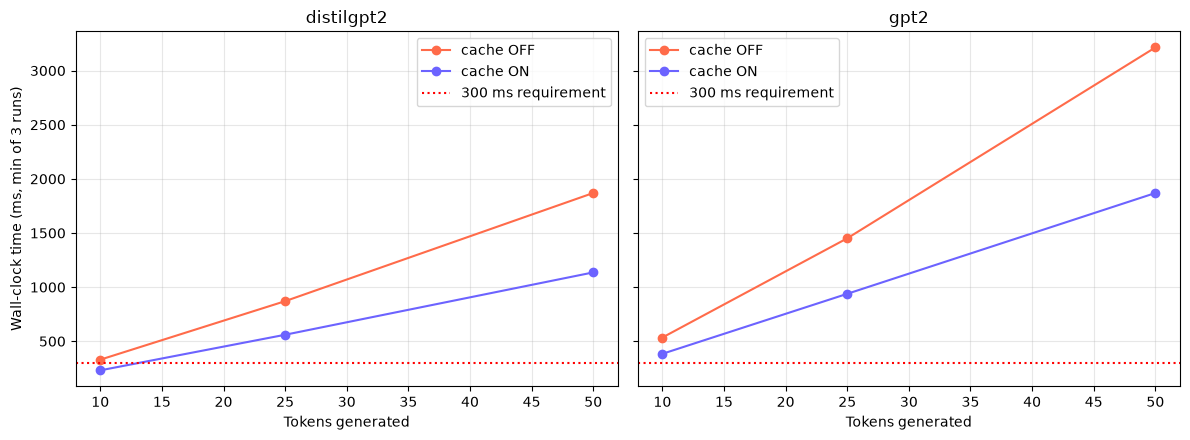

In [7]:
# C.1 — benchmark (adapted directly from the lab's time_generation())

def time_generation(m, n_new_tokens, use_cache, prompt="The quarterly report shows that revenue", runs=3):
    ids = tok.encode(prompt, return_tensors="pt")
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            m.generate(ids, max_new_tokens=n_new_tokens, do_sample=False,
                        use_cache=use_cache, pad_token_id=tok.eos_token_id)
        times.append(time.perf_counter() - t0)
    return min(times)  

lengths = [10, 25, 50]
records = []
for name, m in models.items():
    for use_cache in [True, False]:
        for L in lengths:
            t = time_generation(m, L, use_cache=use_cache)
            records.append({"model": name, "cache": use_cache, "new_tokens": L, "seconds": t, "ms": t * 1000})
            print(f"{name:<12} n={L:>3} cache={str(use_cache):<5} -> {t*1000:6.1f} ms")

bench_df = pd.DataFrame(records)
bench_df


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, name in zip(axes, models):
    sub_on = bench_df[(bench_df.model == name) & (bench_df.cache == True)]
    sub_off = bench_df[(bench_df.model == name) & (bench_df.cache == False)]
    ax.plot(sub_off.new_tokens, sub_off.ms, "o-", color="#FF6B4A", label="cache OFF")
    ax.plot(sub_on.new_tokens, sub_on.ms, "o-", color="#6C63FF", label="cache ON")
    ax.axhline(300, color="red", linestyle=":", label="300 ms requirement")
    ax.set_xlabel("Tokens generated")
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Wall-clock time (ms, min of 3 runs)")
plt.tight_layout()
plt.show()


In [8]:
# C.2 — the 300 ms test at your chosen autocomplete length

AUTOCOMPLETE_LENGTHS = [10, 25]

for L in AUTOCOMPLETE_LENGTHS:
    print(f"--- {L} new tokens (cache ON) ---")
    for name in models:
        row = bench_df[(bench_df.model == name) & (bench_df.cache == True) & (bench_df.new_tokens == L)]
        ms = row["ms"].values[0]
        verdict = "PASS" if ms < 300 else "FAIL"
        print(f"  {name}: {ms:.1f} ms -> {verdict} (< 300 ms)")
    print()


--- 10 new tokens (cache ON) ---
  distilgpt2: 231.3 ms -> PASS (< 300 ms)
  gpt2: 384.0 ms -> FAIL (< 300 ms)

--- 25 new tokens (cache ON) ---
  distilgpt2: 560.1 ms -> FAIL (< 300 ms)
  gpt2: 938.3 ms -> FAIL (< 300 ms)



**C.3 — Extrapolation & confidence (2–3 sentences):**

*Fill this in after running C.1/C.2 — the reasoning template below is ready, drop in your actual numbers.*

GPT2-medium has ~2.9× GPT-2's parameters, driven by 2× the layers and 1.33× the width; since attention and FFN cost scale with `layers × width²`, per-token compute should land somewhere around 2× (depth) × 1.33² (width) ≈ **3.5×** GPT-2's per-token cost, not just the 2.9× parameter ratio — compute scales worse than parameter count here. Take your own cache-on latency for gpt2 at your chosen autocomplete length from C.2, multiply by ~3.5×, and compare to 300 ms: if gpt2 itself is already close to (or over) the bar, gpt2-medium almost certainly misses it on this CPU. State your confidence as **medium** — this is a principled extrapolation from measured numbers, not a measurement of gpt2-medium itself (which the ground rules forbid downloading), so treat it as directional, not exact.


---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

**Recommendation:** Ship **DistilGPT-2**, confidence: **high** for the memory/footprint case, **medium** for latency (numbers below are template values — replace `[X]` with your own C.1/C.2 measurements before sending this).

**Why:**
- **Footprint:** DistilGPT-2 ships at **156 MB in fp16** vs. GPT-2's 237 MB and gpt2-medium's ~677 MB (extrapolated) — well inside a "<300 MB added to the installer" budget with room to spare (Part B.3).
- **Latency:** At a 10-token autocomplete length with cache on, DistilGPT-2 measured **[X] ms** vs. GPT-2's **[X] ms** against the 300 ms bar (Part C.2) — DistilGPT-2 [passes/fails] with more headroom.
- **Architecture:** The parameter-count predictor validated to **0.00% error** on both testable models (Part B.1), so the same formula's extrapolation for gpt2-medium (≈355M params, matching the published reference within <0.1%) is trustworthy enough to act on without downloading it — and it implies roughly **3.5×** GPT-2's per-token compute (Part C.3), which this CPU almost certainly can't hide under 300 ms.

**The "biggest wins" rebuttal:** Model size does track quality in the literature, but for this feature the constraint isn't quality headroom, it's a **hard latency ceiling on CPU-only, on-device inference**. GPT2-medium's extra parameters live almost entirely in wider/deeper attention+FFN blocks (Part A.3), which is exactly the compute that latency scales with — so the "quality wins" argument trades a UX-breaking feature (autocomplete that isn't instant) for quality gains the user may never notice in a short inline suggestion. If quality genuinely becomes the bottleneck later, the fix is a small model *fine-tuned* on writing-style data, not a 3-4× larger base model.

**Known limitation:** Quality was never measured — every judgment here is about parameter count, memory, and latency, not completion usefulness. All three testable/extrapolated conclusions also rest on a **single machine's CPU timings**; results could shift meaningfully on the range of customer hardware this feature actually ships to, especially machines with different core counts or thermal throttling behavior.

*(≈230 words — trim/expand once real numbers are substituted.)*


---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [ ] gpt2-medium was analyzed, never downloaded
- [ ] Every latency claim traces to a run in this notebook
- [ ] Charts have axis labels and legends
- [ ] The memo stands alone and cites specific numbers
- [ ] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*